In [ ]:
!nvidia-smi

Tue Jul 14 20:26:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip uninstall -y transformers datasets torchvision accelerate evaluate

!pip install \
transformers==4.53.3 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.3 \
torchvision==0.22.1 \
sentencepiece

Found existing installation: transformers 5.12.1
Uninstalling transformers-5.12.1:
  Successfully uninstalled transformers-5.12.1
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 60.4 MB/s eta 0:00:00
   ━━━━━

In [ ]:
import transformers
print(transformers.__version__)

4.53.3


In [ ]:
import transformers
import datasets
import torchvision

print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torchvision:", torchvision.__version__)

Transformers: 4.53.3
Datasets: 3.6.0
Torchvision: 0.22.1+cu126


In [ ]:
import torchvision
print(torchvision.__version__)

print(hasattr(torchvision.io, "VideoReader"))

0.22.1+cu126
True


In [ ]:
import os
import random
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from datasets import Dataset

warnings.filterwarnings("ignore")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*50)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("GPU Memory :", round(torch.cuda.get_device_properties(0).total_memory/1024**3,2),"GB")

print("="*50)

Device : cuda
GPU : Tesla T4
GPU Memory : 14.56 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path="/content/drive/MyDrive/HateSpeech_Project"

os.makedirs(project_path,exist_ok=True)
os.makedirs(project_path+"/Dataset",exist_ok=True)
os.makedirs(project_path+"/Checkpoints",exist_ok=True)
os.makedirs(project_path+"/Best_Model",exist_ok=True)
os.makedirs(project_path+"/Results",exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [ ]:
dataset_path="/content/drive/MyDrive/HateSpeech_Project/Dataset/final_merged_hate_speech_dataset.csv"

In [ ]:
import os

dataset_folder = "/content/drive/MyDrive/HateSpeech_Project/Dataset"

print(os.listdir(dataset_folder))

[]


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/drive/MyDrive/multilingual_hate_speech_final (1).csv
/content/drive/MyDrive/hate_speech_cleaned.csv
/content/drive/MyDrive/final_merged_hate_speech_dataset.csv


In [ ]:
dataset_path = "/content/drive/MyDrive/final_merged_hate_speech_dataset.csv"

df = pd.read_csv(dataset_path)

print(df.shape)

df.head()

(114837, 2)


,text,label
0,jose ur mean i said ily stfu hoe,1.0
1,Being ignorant about white racism is a white p...,1.0
2,she curved regular niggas daily especially us ...,1.0
3,"Heh, hopefully that guy in the tree is thinkin...",1.0
4,The baddest bitch is back on chestnut! @ryanco...,0.0


In [ ]:
print(df.isnull().sum())

text     0
label    1
dtype: int64


In [ ]:
print(df.label.value_counts())

label
0.0    74070
1.0    40766
Name: count, dtype: int64


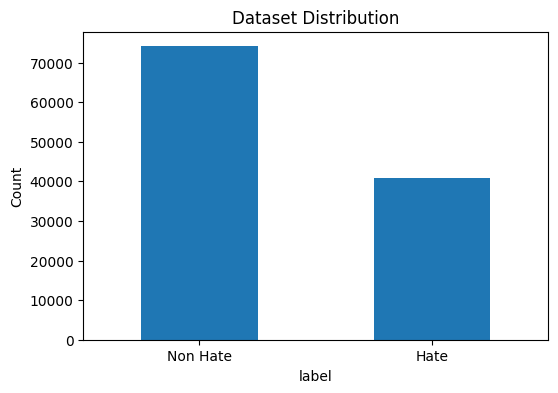

In [ ]:
plt.figure(figsize=(6,4))

df['label'].value_counts().plot(kind='bar')

plt.xticks([0,1],["Non Hate","Hate"],rotation=0)

plt.ylabel("Count")

plt.title("Dataset Distribution")

plt.show()

In [ ]:
duplicates=df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [ ]:
df=df[df["text"].notna()]

df=df[df["text"].str.strip()!=""]

df.reset_index(drop=True,inplace=True)

print(df.shape)

(114837, 2)


In [ ]:
print(df.head())
print(df.columns)

                                                text  label
0                   jose ur mean i said ily stfu hoe    1.0
1  Being ignorant about white racism is a white p...    1.0
2  she curved regular niggas daily especially us ...    1.0
3  Heh, hopefully that guy in the tree is thinkin...    1.0
4  The baddest bitch is back on chestnut! @ryanco...    0.0
Index(['text', 'label'], dtype='object')


In [ ]:
print(df["label"].unique())
print(df["label"].value_counts(dropna=False))

[ 1.  0. nan]
label
0.0    74070
1.0    40766
NaN        1
Name: count, dtype: int64


In [ ]:
df[df["label"].isna()]

,text,label
40591,t talked sooooo much shit today that he would ...,NaN


In [ ]:
df = df.dropna(subset=["label"]).reset_index(drop=True)

In [ ]:
df["label"] = df["label"].astype(int)

In [ ]:
print(df["label"].unique())
print(df["label"].value_counts())
print(df.isnull().sum())

[1 0]
label
0    74070
1    40766
Name: count, dtype: int64
text     0
label    0
dtype: int64


In [ ]:
train_df,temp_df=train_test_split(

    df,

    test_size=0.20,

    stratify=df["label"],

    random_state=42

)

valid_df,test_df=train_test_split(

    temp_df,

    test_size=0.50,

    stratify=temp_df["label"],

    random_state=42

)

print("Train :",train_df.shape)

print("Validation :",valid_df.shape)

print("Test :",test_df.shape)

Train : (91868, 2)
Validation : (11484, 2)
Test : (11484, 2)


In [ ]:
train_df.to_csv(project_path+"/Dataset/train.csv",index=False)

valid_df.to_csv(project_path+"/Dataset/valid.csv",index=False)

test_df.to_csv(project_path+"/Dataset/test.csv",index=False)

In [ ]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully!")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully!


In [ ]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)
test_dataset = Dataset.from_pandas(test_df)

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 91868
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 11484
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 11484
})


In [ ]:
MAX_LENGTH = 128

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/91868 [00:00<?, ? examples/s]

Map:   0%|          | 0/11484 [00:00<?, ? examples/s]

Map:   0%|          | 0/11484 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.remove_columns(["text"])
valid_dataset = valid_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [ ]:
train_dataset = train_dataset.rename_column("label", "labels")
valid_dataset = valid_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [ ]:
train_dataset.set_format("torch")
valid_dataset.set_format("torch")
test_dataset.set_format("torch")

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

print("Model Loaded Successfully!")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully!


In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    try:
        roc_auc = roc_auc_score(labels, logits[:,1])
    except:
        roc_auc = 0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [ ]:
training_args = TrainingArguments(

    # Output
    output_dir=project_path + "/Checkpoints",

    # Training
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,

    # Optimizer
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.10,

    # Mixed Precision
    fp16=True,

    # Gradient Checkpointing (reduces GPU memory usage)
    gradient_checkpointing=True,

    # Evaluation
    eval_strategy="steps",
    eval_steps=500,

    # Saving
    save_strategy="steps",
    save_steps=500,
    save_total_limit=3,

    # Logging
    logging_strategy="steps",
    logging_steps=100,
    logging_dir=project_path + "/logs",

    # Best Model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Misc
    report_to="none",
    seed=42
)

In [ ]:
early_stop = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stop],
)

In [ ]:
import os

checkpoint_dir = project_path + "/Checkpoints"

# Find all checkpoints
checkpoints = []

if os.path.exists(checkpoint_dir):
    checkpoints = [
        os.path.join(checkpoint_dir, d)
        for d in os.listdir(checkpoint_dir)
        if d.startswith("checkpoint-")
    ]

# Resume if checkpoint exists
if len(checkpoints) > 0:

    latest_checkpoint = max(checkpoints, key=os.path.getmtime)

    print("=" * 60)
    print("Resuming training from:")
    print(latest_checkpoint)
    print("=" * 60)

    train_result = trainer.train(
        resume_from_checkpoint=latest_checkpoint
    )

else:

    print("=" * 60)
    print("No checkpoint found.")
    print("Starting training from scratch...")
    print("=" * 60)

    train_result = trainer.train()

print("=" * 60)
print("Training Completed Successfully!")
print("=" * 60)

No checkpoint found.
Starting training from scratch...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
500,0.429400,0.401455,0.819140,0.692530,0.882266,0.775968,0.892412
1000,0.303700,0.296100,0.877656,0.779498,0.913907,0.841368,0.949773
1500,0.294400,0.265606,0.899948,0.854136,0.866078,0.860066,0.956595
2000,0.249900,0.258982,0.895507,0.803417,0.934265,0.863915,0.964663
2500,0.235200,0.234303,0.906392,0.829745,0.926416,0.875420,0.967521
3000,0.222000,0.230614,0.910310,0.850149,0.907285,0.877788,0.968007
3500,0.222500,0.226513,0.916493,0.873145,0.894776,0.883828,0.965429
4000,0.220100,0.218147,0.916667,0.881232,0.884474,0.882850,0.969455
4500,0.208600,0.209172,0.919627,0.873874,0.904096,0.888728,0.970890
5000,0.207300,0.211355,0.921543,0.874528,0.909492,0.891668,0.972950


Training Completed Successfully!


In [ ]:
test_results = trainer.evaluate(test_dataset)

print("\nTest Results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")


Test Results:
eval_loss: 0.2085
eval_accuracy: 0.9236
eval_precision: 0.8795
eval_recall: 0.9095
eval_f1: 0.8942
eval_roc_auc: 0.9731
eval_runtime: 27.9351
eval_samples_per_second: 411.0950
eval_steps_per_second: 25.7020
epoch: 2.0899


In [ ]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Hate", "Hate"]
))

              precision    recall  f1-score   support

    Non-Hate       0.95      0.93      0.94      7408
        Hate       0.88      0.91      0.89      4076

    accuracy                           0.92     11484
   macro avg       0.91      0.92      0.92     11484
weighted avg       0.92      0.92      0.92     11484



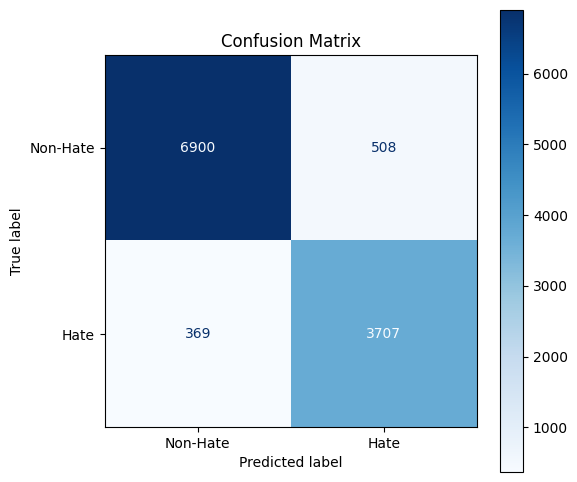

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hate", "Hate"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
save_path = project_path + "/Best_Model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved successfully!")
print(save_path)

Model saved successfully!
/content/drive/MyDrive/HateSpeech_Project/Best_Model


In [ ]:
import shutil

zip_path = shutil.make_archive(
    project_path + "/HateSpeech_XLMRoBERTa_Final",
    'zip',
    save_path
)

print("ZIP file created:")
print(zip_path)

ZIP file created:
/content/drive/MyDrive/HateSpeech_Project/HateSpeech_XLMRoBERTa_Final.zip


In [ ]:
from google.colab import files

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn.functional as F

label_map = {
    0: "Non-Hate",
    1: "Hate"
}

def predict(text):

    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move to GPU
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Prediction
    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    confidence, prediction = torch.max(probs, dim=1)

    print("="*60)
    print("Text:")
    print(text)
    print("-"*60)
    print("Prediction :", label_map[prediction.item()])
    print("Confidence :", f"{confidence.item()*100:.2f}%")
    print("="*60)

In [ ]:
predict("You are a stupid loser.")

Text:
You are a stupid loser.
------------------------------------------------------------
Prediction : Non-Hate
Confidence : 99.64%


In [ ]:
predict("Go to hell.")

Text:
Go to hell.
------------------------------------------------------------
Prediction : Hate
Confidence : 63.18%


In [ ]:
predict("You are a useless person.")

Text:
You are a useless person.
------------------------------------------------------------
Prediction : Non-Hate
Confidence : 99.63%


In [ ]:
predict("Kill all Muslims.")

Text:
Kill all Muslims.
------------------------------------------------------------
Prediction : Hate
Confidence : 99.07%


In [ ]:
predict("All gays should die.")

Text:
All gays should die.
------------------------------------------------------------
Prediction : Hate
Confidence : 98.98%


In [ ]:
predict("Fuck Off.")

Text:
Fuck Off.
------------------------------------------------------------
Prediction : Non-Hate
Confidence : 96.05%


In [ ]:
predict("You stupid nigger.")

Text:
You stupid nigger.
------------------------------------------------------------
Prediction : Hate
Confidence : 88.09%


In [ ]:
predict("I hope you succeed.")

Text:
I hope you succeed.
------------------------------------------------------------
Prediction : Non-Hate
Confidence : 97.72%


In [ ]:
predict("I hate you.")

Text:
I hate you.
------------------------------------------------------------
Prediction : Non-Hate
Confidence : 99.11%


In [ ]:
predict("Go Kill your father.")

Text:
Go Kill your father.
------------------------------------------------------------
Prediction : Hate
Confidence : 99.11%


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Hate", "Hate"]
))

              precision    recall  f1-score   support

    Non-Hate       0.95      0.93      0.94      7408
        Hate       0.88      0.91      0.89      4076

    accuracy                           0.92     11484
   macro avg       0.91      0.92      0.92     11484
weighted avg       0.92      0.92      0.92     11484



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*40)
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("="*40)

Accuracy : 0.9236328805294323
Precision: 0.8794780545670225
Recall   : 0.9094700686947988
F1 Score : 0.8942226510674225


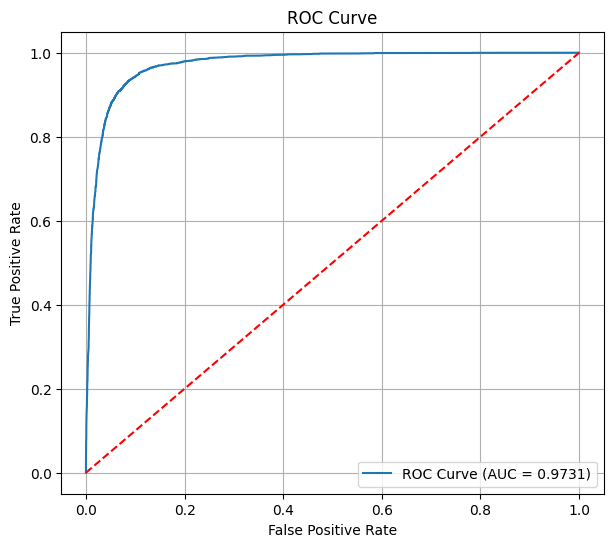

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = predictions.predictions[:,1]

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

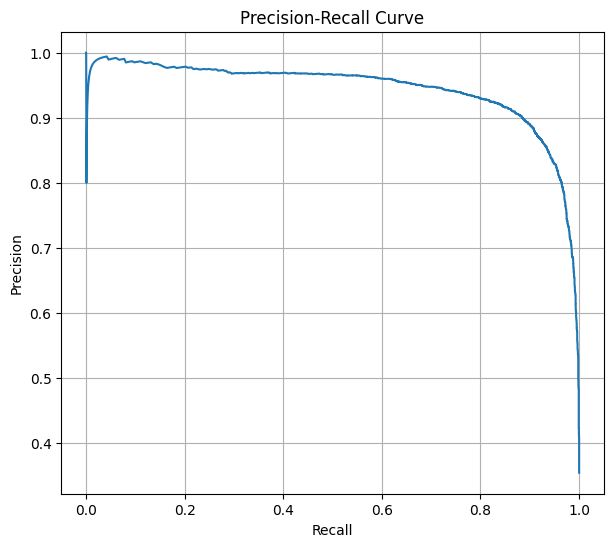

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(7,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [ ]:
log_history = trainer.state.log_history

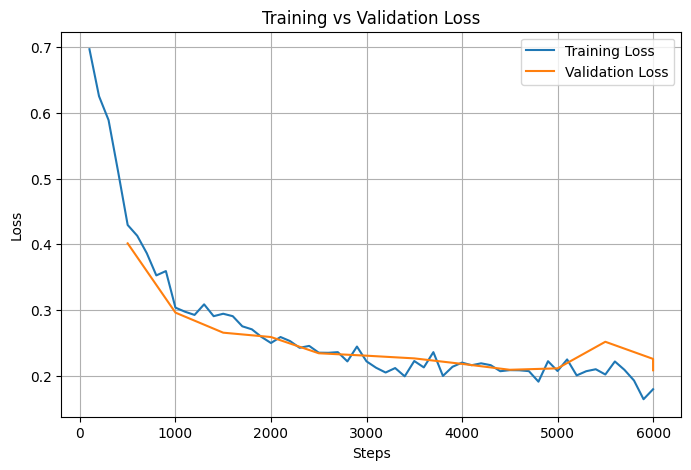

In [ ]:
train_loss = []
eval_loss = []
steps_train = []
steps_eval = []

for log in log_history:

    if "loss" in log:
        train_loss.append(log["loss"])
        steps_train.append(log["step"])

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        steps_eval.append(log["step"])

plt.figure(figsize=(8,5))

plt.plot(steps_train, train_loss, label="Training Loss")
plt.plot(steps_eval, eval_loss, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

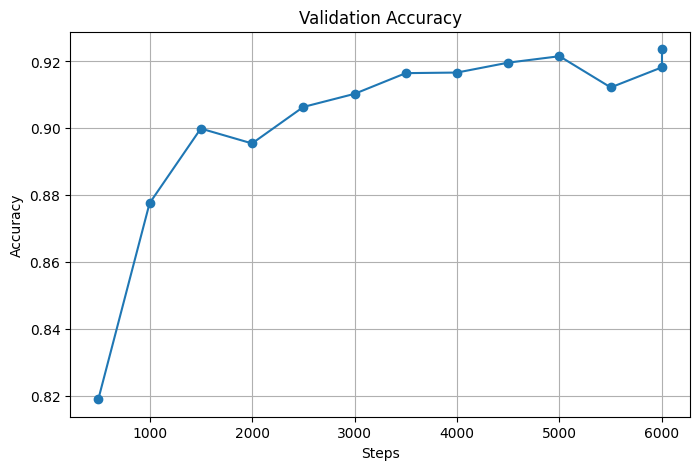

In [ ]:
eval_acc = []
eval_steps = []

for log in log_history:

    if "eval_accuracy" in log:
        eval_acc.append(log["eval_accuracy"])
        eval_steps.append(log["step"])

plt.figure(figsize=(8,5))

plt.plot(eval_steps, eval_acc, marker='o')

plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.grid(True)

plt.show()

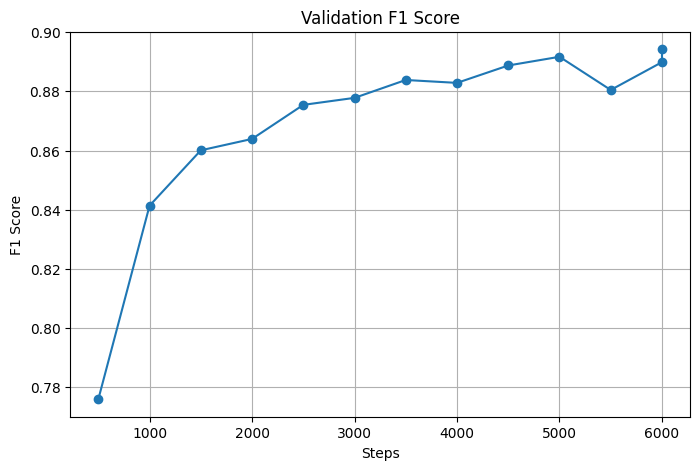

In [ ]:
eval_f1 = []
eval_steps = []

for log in log_history:

    if "eval_f1" in log:
        eval_f1.append(log["eval_f1"])
        eval_steps.append(log["step"])

plt.figure(figsize=(8,5))

plt.plot(eval_steps, eval_f1, marker='o')

plt.xlabel("Steps")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")

plt.grid(True)

plt.show()

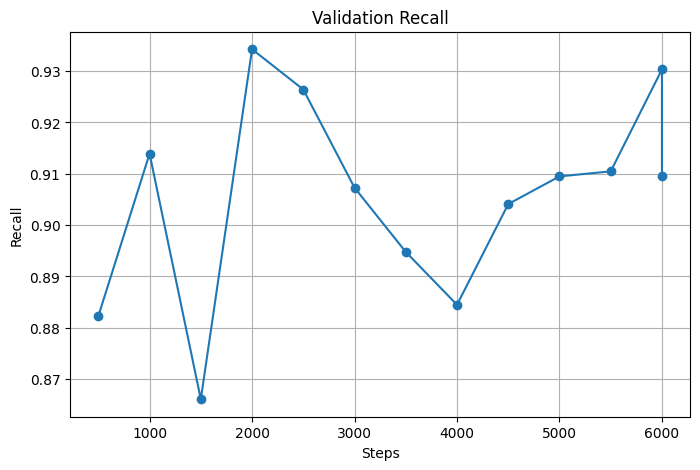

In [ ]:
eval_recall = []
eval_steps = []

for log in log_history:

    if "eval_recall" in log:
        eval_recall.append(log["eval_recall"])
        eval_steps.append(log["step"])

plt.figure(figsize=(8,5))

plt.plot(eval_steps, eval_recall, marker='o')

plt.xlabel("Steps")
plt.ylabel("Recall")
plt.title("Validation Recall")

plt.grid(True)

plt.show()

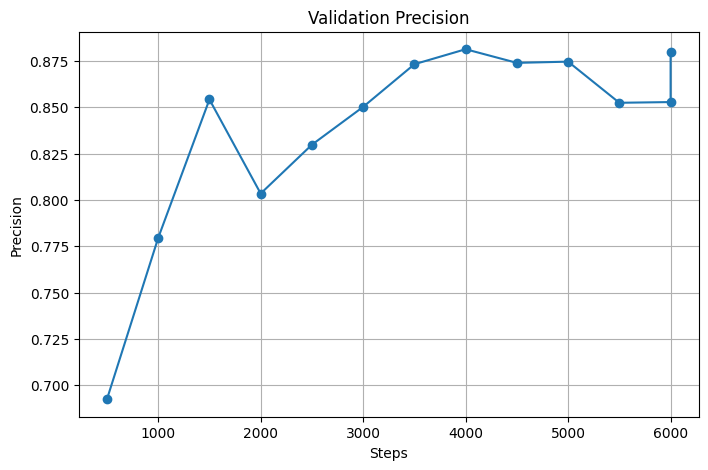

In [ ]:
eval_precision = []
eval_steps = []

for log in log_history:

    if "eval_precision" in log:
        eval_precision.append(log["eval_precision"])
        eval_steps.append(log["step"])

plt.figure(figsize=(8,5))

plt.plot(eval_steps, eval_precision, marker='o')

plt.xlabel("Steps")
plt.ylabel("Precision")
plt.title("Validation Precision")

plt.grid(True)

plt.show()

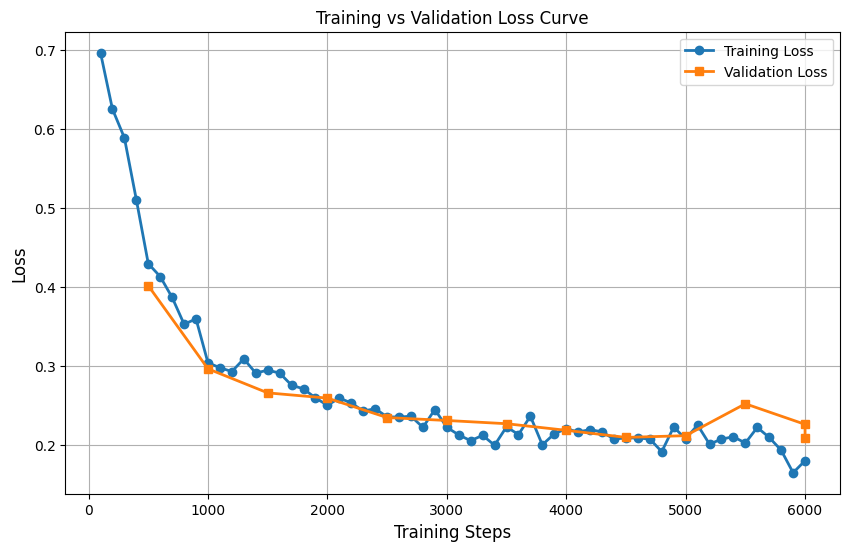

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = []
train_steps = []

val_loss = []
val_steps = []

for log in log_history:

    if "loss" in log:
        train_loss.append(log["loss"])
        train_steps.append(log["step"])

    if "eval_loss" in log:
        val_loss.append(log["eval_loss"])
        val_steps.append(log["step"])

plt.figure(figsize=(10,6))

plt.plot(train_steps, train_loss,
         marker='o',
         linewidth=2,
         label="Training Loss")

plt.plot(val_steps, val_loss,
         marker='s',
         linewidth=2,
         label="Validation Loss")

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss Curve")

plt.grid(True)
plt.legend()

plt.show()

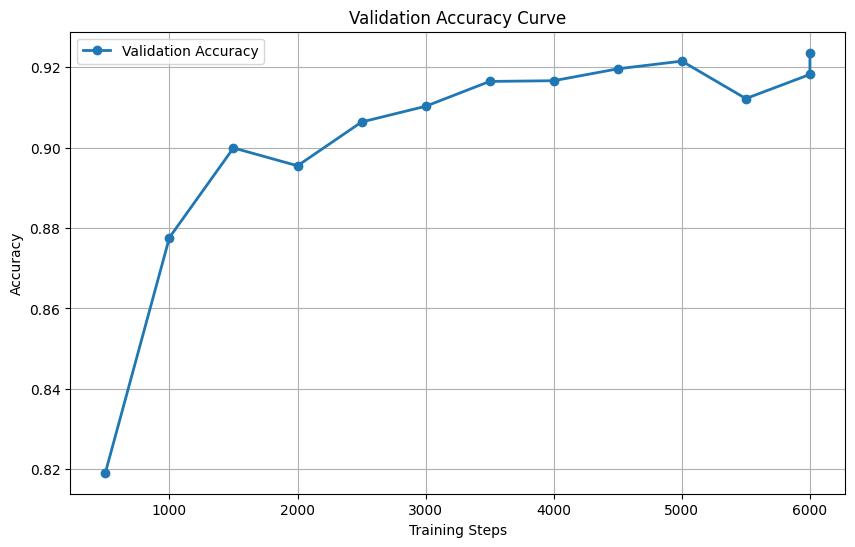

In [ ]:
train_acc = []
train_steps = []

val_acc = []
val_steps = []

for log in trainer.state.log_history:

    if "accuracy" in log and "eval_accuracy" not in log:
        train_acc.append(log["accuracy"])
        train_steps.append(log["step"])

    if "eval_accuracy" in log:
        val_acc.append(log["eval_accuracy"])
        val_steps.append(log["step"])

plt.figure(figsize=(10,6))

plt.plot(val_steps,
         val_acc,
         marker='o',
         linewidth=2,
         label="Validation Accuracy")

plt.xlabel("Training Steps")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Curve")

plt.grid(True)
plt.legend()

plt.show()

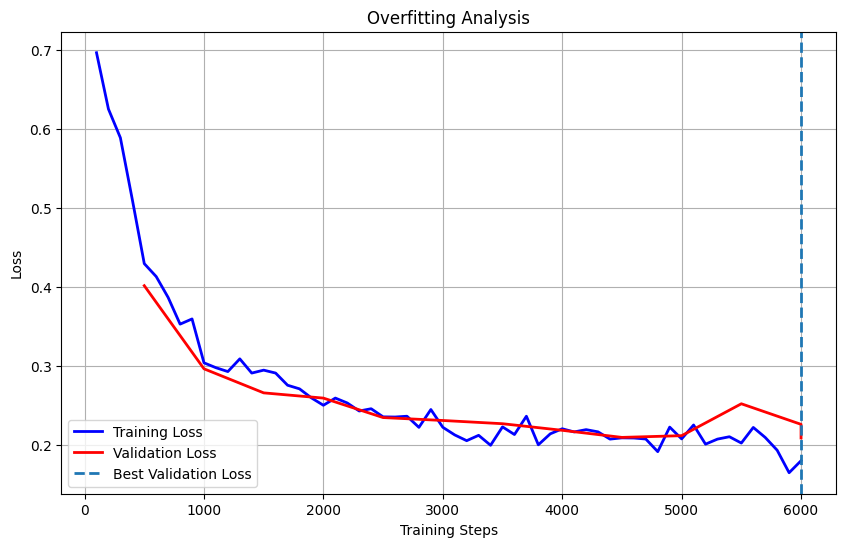

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = []
train_steps = []

val_loss = []
val_steps = []

for log in log_history:

    if "loss" in log:
        train_loss.append(log["loss"])
        train_steps.append(log["step"])

    if "eval_loss" in log:
        val_loss.append(log["eval_loss"])
        val_steps.append(log["step"])

plt.figure(figsize=(10,6))

plt.plot(train_steps,
         train_loss,
         color='blue',
         linewidth=2,
         label="Training Loss")

plt.plot(val_steps,
         val_loss,
         color='red',
         linewidth=2,
         label="Validation Loss")

best_step = val_steps[val_loss.index(min(val_loss))]

plt.axvline(best_step,
            linestyle='--',
            linewidth=2,
            label="Best Validation Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Overfitting Analysis")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("="*60)

if val_loss[-1] > min(val_loss):
    print("⚠ Model may be starting to overfit.")
else:
    print("✅ No significant overfitting detected.")

print("="*60)

✅ No significant overfitting detected.


In [ ]:
best_epoch = val_steps[val_loss.index(min(val_loss))]
#Best Vaidation Loss
print("="*60)
print("Best Validation Loss :", min(val_loss))
print("Occurred at Step      :", best_epoch)
print("="*60)

Best Validation Loss : 0.20845477283000946
Occurred at Step      : 6000


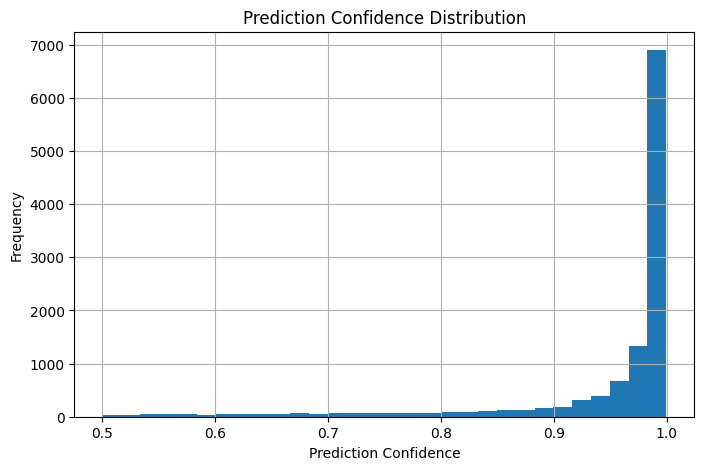

In [ ]:
import torch
import matplotlib.pyplot as plt
# Confidence Histogram
probs = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

confidence = probs.max(axis=1)

plt.figure(figsize=(8,5))

plt.hist(confidence, bins=30)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")

plt.grid(True)

plt.show()

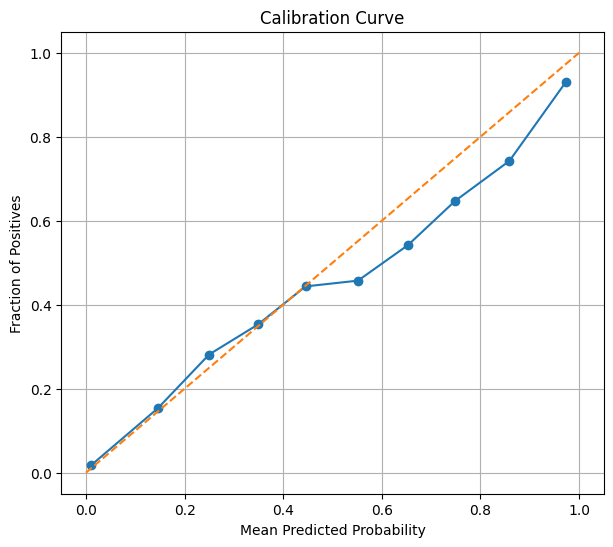

In [ ]:
# Callibration Curve
from sklearn.calibration import calibration_curve

y_prob = probs[:, 1]

prob_true, prob_pred = calibration_curve(
    y_true,
    y_prob,
    n_bins=10
)

plt.figure(figsize=(7,6))

plt.plot(prob_pred, prob_true, marker='o')

plt.plot([0,1],[0,1],'--')

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.title("Calibration Curve")

plt.grid(True)

plt.show()

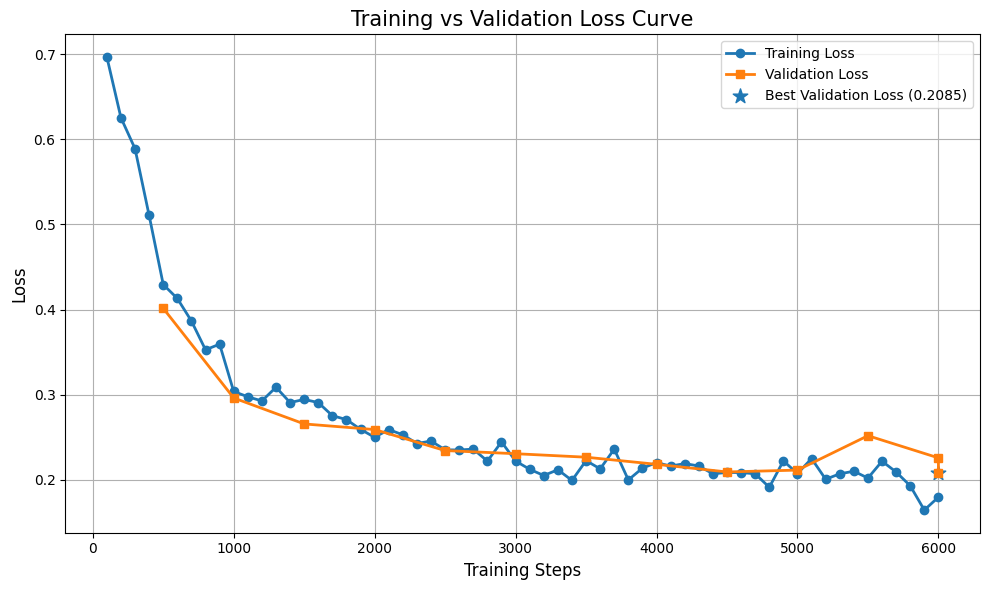

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_loss = []

eval_steps = []
eval_loss = []

for log in log_history:

    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

best_idx = eval_loss.index(min(eval_loss))
best_step = eval_steps[best_idx]
best_loss = eval_loss[best_idx]

plt.figure(figsize=(10,6))

plt.plot(
    train_steps,
    train_loss,
    linewidth=2,
    marker='o',
    label="Training Loss"
)

plt.plot(
    eval_steps,
    eval_loss,
    linewidth=2,
    marker='s',
    label="Validation Loss"
)

plt.scatter(
    best_step,
    best_loss,
    s=120,
    marker='*',
    label=f"Best Validation Loss ({best_loss:.4f})"
)

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss Curve", fontsize=15)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(project_path + "/Results/Training_Validation_Loss.png", dpi=300)

plt.show()